# This is just for fun

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("unique_scrandle_cases_2.csv")

#df.head()

beer_df = df[
    df["title"].str.contains("beer", case=False, na=False) |
    df["subtitle"].str.contains("beer", case=False, na=False)
] #Whilke har oel?



In [49]:
titles = df["title"].tolist()
subtitles = df["subtitle"].tolist()
prices = df["price"].tolist()
ratings = df["rating"].tolist()
hashes = df["image_hash"].tolist()
occurrences = df["occurrences"].tolist()


In [50]:
# Count occurrences per row
df["n_appear"] = df["occurrences"].apply(lambda x: len(x.split(" | ")))
print(df["n_appear"])

0       7
1       1
2       6
3       4
4       5
       ..
4583    1
4584    1
4585    1
4586    1
4587    1
Name: n_appear, Length: 4588, dtype: int64


In [51]:
n_beer = len(beer_df)
n_total = len(df)

print(f"Beer cases: {n_beer}")
print(f"Total cases: {n_total}")


mean_beer = beer_df["rating"].mean()
mean_all = df["rating"].mean()

print(f"Average rating (beer): {mean_beer:.2f}")
print(f"Average rating (all):  {mean_all:.2f}")

Beer cases: 102
Total cases: 4588
Average rating (beer): 53.74
Average rating (all):  52.85


In [52]:
std_beer = beer_df["rating"].std()
std_all = df["rating"].std()

print(f"Std (beer): {std_beer:.2f}")
print(f"Std (all):  {std_all:.2f}")


Std (beer): 23.73
Std (all):  26.09


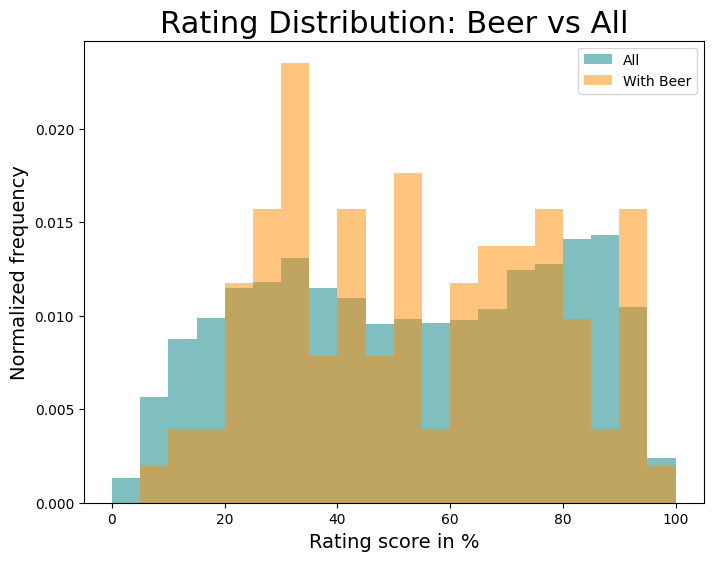

In [53]:
bins = np.arange(0, 105, 5)



plt.figure(figsize = (8,6))
plt.hist(df["rating"], bins=bins, alpha=0.5, label="All", density = True, color = "teal")
plt.hist(beer_df["rating"], bins=bins, alpha=0.5, label="With Beer" , density  = True, color = "darkorange")

plt.legend()
plt.xlabel("Rating score in %", fontsize = 14 )
plt.ylabel("Normalized frequency", fontsize = 14)
plt.title("Rating Distribution: Beer vs All", fontsize = 22)
plt.show()


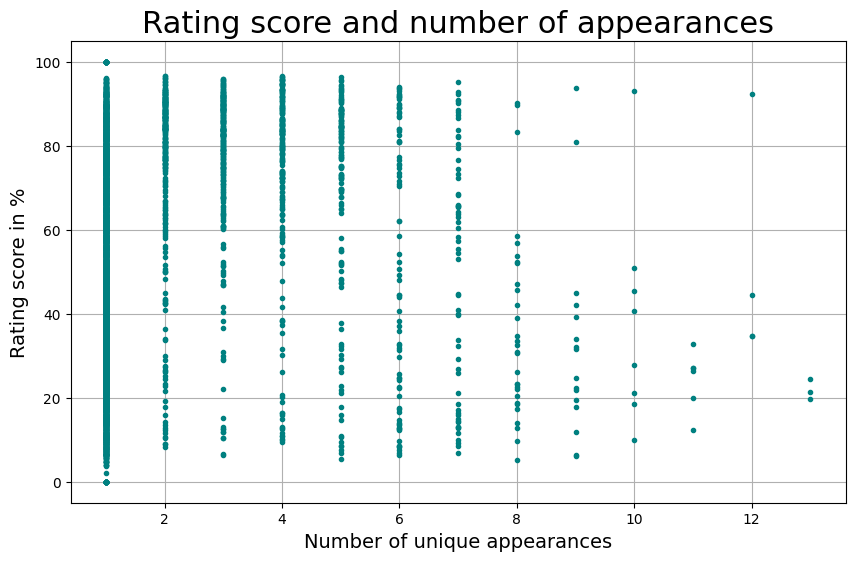

In [54]:
plt.figure(figsize = (10,6))

plt.plot(df["n_appear"], df["rating"], '.',color = 'teal')

plt.xlabel('Number of unique appearances', fontsize  = 14)
plt.ylabel('Rating score in %', fontsize = 14)
plt.title('Rating score and number of appearances', fontsize = 22)
plt.grid()
plt.show()





In [71]:
mask = df['price'] == df['price']
print(mask)

Jakobs_rate = df['rating'][mask]
Jakobs_price = df['price'][mask]
Jakobs_price

0       True
1       True
2       True
3       True
4       True
        ... 
4583    True
4584    True
4585    True
4586    True
4587    True
Name: price, Length: 4588, dtype: bool


0        2.60
1        9.50
2        2.80
3        3.40
4        5.50
        ...  
4583     5.20
4584     3.40
4585     5.50
4586    16.45
4587     7.95
Name: price, Length: 4251, dtype: float64

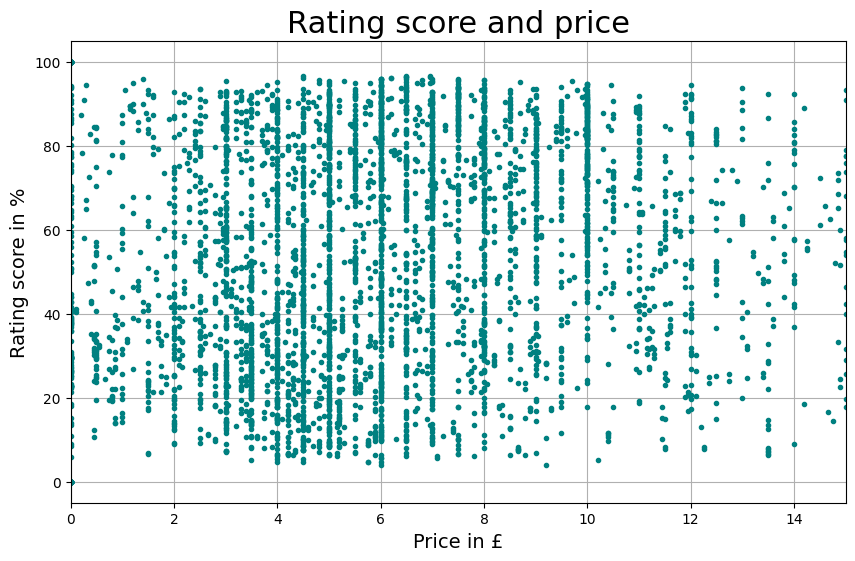

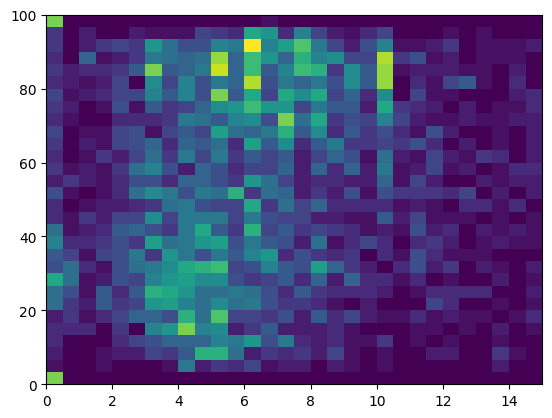

In [80]:
plt.figure(figsize = (10,6))

plt.plot( df["price"], df["rating"], '.',color = 'teal')

plt.xlabel('Price in £', fontsize  = 14)
plt.ylabel('Rating score in %', fontsize = 14)
plt.title('Rating score and price', fontsize = 22)
plt.grid()
plt.xlim([0,15])
plt.show()

plt.hist2d(Jakobs_price, Jakobs_rate, bins  =30, range  = [[0,15],[0,100]])
plt.xlim([0,15])
plt.show()

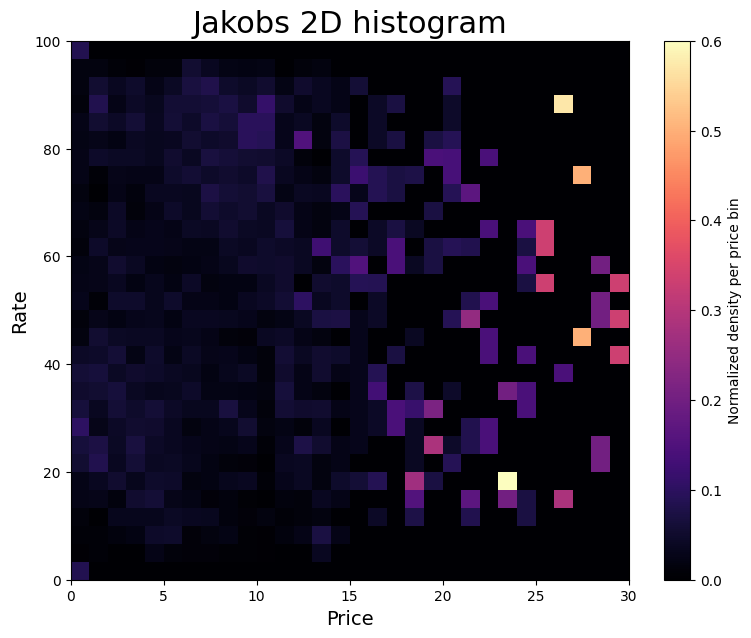

In [ ]:
# Compute 2D histogram
H, xedges, yedges = np.histogram2d(
    Jakobs_price, Jakobs_rate,
    bins=30,
    range=[[0, 15], [0, 100]]
)

# Normalize each column (along y-axis)
H_norm = H / H.sum(axis=1, keepdims=True)  # normalize per price bin

# Avoid division by zero
H_norm = np.nan_to_num(H_norm)

# Plot
plt.figure(figsize = (9,7))
plt.pcolormesh(xedges, yedges, H_norm.T, shading='auto', cmap = 'magma')
plt.colorbar(label='Normalized density per price bin')
plt.title('Jakobs 2D histogram', fontsize = 22)
plt.xlabel('Price', fontsize = 14)
plt.ylabel('Rate', fontsize = 14)
plt.show()